
# E-Commerce Sales Data Analysis & EDA
# Internship Project - Horizon TechX
# Name: Karthik Neduri
# Domain: AI & Data Science



# Step 1: Import necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Step 2: Load the dataset

In [ ]:
df = pd.read_csv('data.csv', encoding='unicode_escape')

# Step 3: First look at the data

In [ ]:
print("=== FIRST 5 ROWS OF DATASET ===")
print(df.head())

=== FIRST 5 ROWS OF DATASET ===
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  12-01-2010 08:26       2.55     17850.0  United Kingdom  
1  12-01-2010 08:26       3.39     17850.0  United Kingdom  
2  12-01-2010 08:26       2.75     17850.0  United Kingdom  
3  12-01-2010 08:26       3.39     17850.0  United Kingdom  
4  12-01-2010 08:26       3.39     17850.0  United Kingdom  


In [ ]:
print("\n=== SHAPE OF DATASET (Rows, Columns) ===")
print(df.shape)


=== SHAPE OF DATASET (Rows, Columns) ===
(541909, 8)


In [ ]:
print("\n=== COLUMN NAMES ===")
print(df.columns.tolist())


=== COLUMN NAMES ===
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [ ]:
print("\n=== DATA TYPES ===")
print(df.dtypes)


=== DATA TYPES ===
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


# Step 4: Check Missing Values & Basic Statistics

In [ ]:
print("=== MISSING VALUES IN EACH COLUMN ===")
print(df.isnull().sum())

=== MISSING VALUES IN EACH COLUMN ===
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [ ]:
print("\n=== MISSING VALUES PERCENTAGE ===")
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent.round(2))


=== MISSING VALUES PERCENTAGE ===
InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64


In [ ]:
print("\n=== BASIC STATISTICS OF DATASET ===")
print(df.describe())


=== BASIC STATISTICS OF DATASET ===
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000


In [ ]:
print("\n=== TOTAL NUMBER OF UNIQUE CUSTOMERS ===")
print(df['CustomerID'].nunique())


=== TOTAL NUMBER OF UNIQUE CUSTOMERS ===
4372


In [ ]:
print("\n=== TOTAL NUMBER OF UNIQUE COUNTRIES ===")
print(df['Country'].nunique())


=== TOTAL NUMBER OF UNIQUE COUNTRIES ===
38


In [ ]:
print("\n=== TOTAL NUMBER OF UNIQUE PEODUCTS")
print(df['Description'].nunique())


=== TOTAL NUMBER OF UNIQUE PEODUCTS
4223


# Step 5: Data Cleaning

# 5.1 Remove rows with missing Description

In [ ]:
df = df.dropna(subset=['Description'])
print("✅ Removed missing Descriptions")

✅ Removed missing Descriptions


# 5.2 Remove rows with missing InvoiceDate, UnitPrice, Quantity, Country

In [ ]:
df = df.dropna(subset=['InvoiceDate', 'UnitPrice', 'Quantity', 'Country'])
print("✅ Removed missing InvoiceDate, UnitPrice, Quantity, Country")

✅ Removed missing InvoiceDate, UnitPrice, Quantity, Country


# 5.3 Remove cancelled orders (InvoiceNo starting with 'C')

In [ ]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print("✅ Removed cancelled orders")

✅ Removed cancelled orders


# 5.4 Remove negative Quantity values

In [ ]:
df = df[df['Quantity'] > 0]
print("✅ Removed negative Quantity values")

✅ Removed negative Quantity values


# 5.5  Remove negative UnitPrice values

In [ ]:
df = df[df['UnitPrice'] > 0]
print("✅ Removed negative UnitPrice values")

✅ Removed negative UnitPrice values


# 5.6 Create new column: Total Price

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
print("✅ Created TotalPrice column")

✅ Created TotalPrice column


# 5.7 Convert InvoiceDate to datetime format


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')
print("✅ Converted InvoiceDate to datetime format")

✅ Converted InvoiceDate to datetime format


# 5.8 Extract Month and Year from InvoiceDate

In [ ]:
df['Month'] = df['InvoiceDate'].dt.month
df['Year'] = df['InvoiceDate'].dt.year
print("✅ Extracted Month and Year")

✅ Extracted Month and Year


# 5.9 Check cleaned dataset shape

In [ ]:
print("\n=== CLEANED DATASET SHAPE ===")
print(df.shape)

print("\n=== MISSING VALUES AFTER CLEANING ===")
print(df.isnull().sum())

print("\n=== FIRST 5 ROWS AFTER CLEANING ===")
print(df.head())


=== CLEANED DATASET SHAPE ===
(530104, 11)

=== MISSING VALUES AFTER CLEANING ===
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132220
Country             0
TotalPrice          0
Month               0
Year                0
dtype: int64

=== FIRST 5 ROWS AFTER CLEANING ===
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  \
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom       15.30   
1 2010-12-01 08:26:00       3.39     178

# Step 6: Professional Business Overview

In [ ]:
print("=" * 60)
print("       E-COMMERCE BUSINESS PERFORMANCE OVERVIEW")
print("=" * 60)

       E-COMMERCE BUSINESS PERFORMANCE OVERVIEW


# 6.1. Total Revenue Generated

In [ ]:
total_revenue = df['TotalPrice'].sum()
print(f"\n💰 TOTAL REVENUE GENERATED    : £ {total_revenue:,.2f}")


💰 TOTAL REVENUE GENERATED    : £ 10,666,684.54


# 6.2. Total Number of Orders

In [ ]:
total_orders = df['InvoiceNo'].nunique()
print(f"📦 TOTAL NUMBER OF ORDERS      : {total_orders:,}")

📦 TOTAL NUMBER OF ORDERS      : 19,960


# 6.3. Total Number of Customers

In [ ]:
total_customers = df['CustomerID'].nunique()
print(f"👥 TOTAL NUMBER OF CUSTOMERS   : {total_customers:,}")

👥 TOTAL NUMBER OF CUSTOMERS   : 4,338


# 6.4. Total Number of Products

In [ ]:
total_products = df['Description'].nunique()
print(f"🛒 TOTAL UNIQUE PRODUCTS       : {total_products:,}")

🛒 TOTAL UNIQUE PRODUCTS       : 4,026


# 5.5. Total Number of Countries

In [ ]:
total_countries = df['Country'].nunique()
print(f"🌍 TOTAL COUNTRIES SERVED      : {total_countries:,}")

🌍 TOTAL COUNTRIES SERVED      : 38


# 6.6. Total Items Sold

In [ ]:
total_items = df['Quantity'].sum()
print(f"📊 TOTAL ITEMS SOLD            : {total_items:,.0f}")

📊 TOTAL ITEMS SOLD            : 5,588,376


# 6.7. Average Order Value

In [ ]:
avg_order_value = df.groupby('InvoiceNo')['TotalPrice'].sum().mean()
print(f"💵 AVERAGE ORDER VALUE         : £ {avg_order_value:,.2f}")

💵 AVERAGE ORDER VALUE         : £ 534.40


# 6.8. Highest Single Order Value

In [ ]:
max_order = df.groupby('InvoiceNo')['TotalPrice'].sum().max()
print(f"🏆 HIGHEST SINGLE ORDER VALUE  : £ {max_order:,.2f}")

🏆 HIGHEST SINGLE ORDER VALUE  : £ 168,469.60


# 6.9. Average Items Per Order

In [ ]:
avg_items = df.groupby('InvoiceNo')['Quantity'].sum().mean()
print(f"🛍️  AVERAGE ITEMS PER ORDER     : {avg_items:,.2f}")

🛍️  AVERAGE ITEMS PER ORDER     : 279.98


# 6.10 Date Range of Dataset

In [ ]:
print(f"\n📅 DATA FROM : {df['InvoiceDate'].min().strftime('%d %B %Y')}")
print(f"📅 DATA TO   : {df['InvoiceDate'].max().strftime('%d %B %Y')}")


📅 DATA FROM : 01 December 2010
📅 DATA TO   : 09 December 2011


# 6.11. Best Performing Year

In [ ]:
best_year = df.groupby('Year')['TotalPrice'].sum().idxmax()
best_year_revenue = df.groupby('Year')['TotalPrice'].sum().max()
print(f"\n🌟 BEST PERFORMING YEAR        : {best_year}")
print(f"🌟 BEST YEAR REVENUE           : £ {best_year_revenue:,.2f}")


🌟 BEST PERFORMING YEAR        : 2011
🌟 BEST YEAR REVENUE           : £ 9,842,938.40


# 6.12. Best Performing Month Overall

In [ ]:
best_month = df.groupby('Month')['TotalPrice'].sum().idxmax()
best_month_revenue = df.groupby('Month')['TotalPrice'].sum().max()
import calendar
print(f"\n📈 BEST PERFORMING MONTH       : {calendar.month_name[best_month]}")
print(f"📈 BEST MONTH REVENUE          : £ {best_month_revenue:,.2f}")

print("\n" + "=" * 60)
print("         OVERVIEW ANALYSIS COMPLETE ✅")
print("=" * 60)



📈 BEST PERFORMING MONTH       : November
📈 BEST MONTH REVENUE          : £ 1,509,496.33

         OVERVIEW ANALYSIS COMPLETE ✅


# Step 7: Professional Product & Customer & Country Analysis

#7.1: Top 10 Products by Quantity

In [ ]:
print("=" * 60)
print("         PRODUCT PERFORMANCE ANALYSIS")
print("=" * 60)

print("\n🏆 TOP 10 BEST SELLING PRODUCTS BY QUANTITY:")
print("-" * 60)
top_products_qty = df.groupby('Description')['Quantity'].sum()\
                     .sort_values(ascending=False).head(10)
for i, (product, qty) in enumerate(top_products_qty.items(), 1):
    print(f"{i:2}. {product[:45]:45} : {qty:>10,.0f} units")

         PRODUCT PERFORMANCE ANALYSIS

🏆 TOP 10 BEST SELLING PRODUCTS BY QUANTITY:
------------------------------------------------------------
 1. PAPER CRAFT , LITTLE BIRDIE                   :     80,995 units
 2. MEDIUM CERAMIC TOP STORAGE JAR                :     78,033 units
 3. WORLD WAR 2 GLIDERS ASSTD DESIGNS             :     55,047 units
 4. JUMBO BAG RED RETROSPOT                       :     48,474 units
 5. WHITE HANGING HEART T-LIGHT HOLDER            :     37,891 units
 6. POPCORN HOLDER                                :     36,761 units
 7. ASSORTED COLOUR BIRD ORNAMENT                 :     36,461 units
 8. PACK OF 72 RETROSPOT CAKE CASES               :     36,419 units
 9. RABBIT NIGHT LIGHT                            :     30,788 units
10. MINI PAINT SET VINTAGE                        :     26,633 units


#7.2: Top 10 Products by Revenue

In [ ]:
print("=" * 60)
print("    TOP 10 BEST SELLING PRODUCTS BY REVENUE")
print("=" * 60)

print("\n💰 TOP 10 BEST SELLING PRODUCTS BY REVENUE:")
print("-" * 60)
top_products_rev = df.groupby('Description')['TotalPrice'].sum()\
                     .sort_values(ascending=False).head(10)
for i, (product, rev) in enumerate(top_products_rev.items(), 1):
    print(f"{i:2}. {product[:45]:45} : £ {rev:>10,.2f}")

    TOP 10 BEST SELLING PRODUCTS BY REVENUE

💰 TOP 10 BEST SELLING PRODUCTS BY REVENUE:
------------------------------------------------------------
 1. DOTCOM POSTAGE                                : £ 206,248.77
 2. REGENCY CAKESTAND 3 TIER                      : £ 174,484.74
 3. PAPER CRAFT , LITTLE BIRDIE                   : £ 168,469.60
 4. WHITE HANGING HEART T-LIGHT HOLDER            : £ 106,292.77
 5. PARTY BUNTING                                 : £  99,504.33
 6. JUMBO BAG RED RETROSPOT                       : £  94,340.05
 7. MEDIUM CERAMIC TOP STORAGE JAR                : £  81,700.92
 8. Manual                                        : £  78,112.82
 9. POSTAGE                                       : £  78,101.88
10. RABBIT NIGHT LIGHT                            : £  66,964.99


#7.3: Top 10 Customers by Revenue

In [ ]:
print("=" * 60)
print("         CUSTOMER PERFORMANCE ANALYSIS")
print("=" * 60)

print("\n👥 TOP 10 CUSTOMERS BY REVENUE:")
print("-" * 60)
top_customers = df.groupby('CustomerID')['TotalPrice'].sum()\
                  .sort_values(ascending=False).head(10)
for i, (customer, rev) in enumerate(top_customers.items(), 1):
    print(f"{i:2}. Customer ID: {customer:>10} : £ {rev:>10,.2f}")

         CUSTOMER PERFORMANCE ANALYSIS

👥 TOP 10 CUSTOMERS BY REVENUE:
------------------------------------------------------------
 1. Customer ID:    14646.0 : £ 280,206.02
 2. Customer ID:    18102.0 : £ 259,657.30
 3. Customer ID:    17450.0 : £ 194,550.79
 4. Customer ID:    16446.0 : £ 168,472.50
 5. Customer ID:    14911.0 : £ 143,825.06
 6. Customer ID:    12415.0 : £ 124,914.53
 7. Customer ID:    14156.0 : £ 117,379.63
 8. Customer ID:    17511.0 : £  91,062.38
 9. Customer ID:    16029.0 : £  81,024.84
10. Customer ID:    12346.0 : £  77,183.60


#7.4: Top 10 Customers by Number of Orders

In [ ]:
print("=" * 60)
print("    TOP 10 CUSTOMERS BY NUMBER OF ORDERS")
print("=" * 60)

print("\n📦 TOP 10 CUSTOMERS BY NUMBER OF ORDERS:")
print("-" * 60)
top_customers_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()\
                         .sort_values(ascending=False).head(10)
for i, (customer, orders) in enumerate(top_customers_orders.items(), 1):
    print(f"{i:2}. Customer ID: {customer:>10} : {orders:>5} orders")

    TOP 10 CUSTOMERS BY NUMBER OF ORDERS

📦 TOP 10 CUSTOMERS BY NUMBER OF ORDERS:
------------------------------------------------------------
 1. Customer ID:    12748.0 :   209 orders
 2. Customer ID:    14911.0 :   201 orders
 3. Customer ID:    17841.0 :   124 orders
 4. Customer ID:    13089.0 :    97 orders
 5. Customer ID:    14606.0 :    93 orders
 6. Customer ID:    15311.0 :    91 orders
 7. Customer ID:    12971.0 :    86 orders
 8. Customer ID:    14646.0 :    73 orders
 9. Customer ID:    16029.0 :    63 orders
10. Customer ID:    13408.0 :    62 orders


#7.5: Top 10 Countries by Revenue

In [ ]:
print("=" * 60)
print("         COUNTRY PERFORMANCE ANALYSIS")
print("=" * 60)

print("\n🌍 TOP 10 COUNTRIES BY REVENUE:")
print("-" * 60)
top_countries_rev = df.groupby('Country')['TotalPrice'].sum()\
                      .sort_values(ascending=False).head(10)
for i, (country, rev) in enumerate(top_countries_rev.items(), 1):
    print(f"{i:2}. {country:30} : £ {rev:>12,.2f}")

         COUNTRY PERFORMANCE ANALYSIS

🌍 TOP 10 COUNTRIES BY REVENUE:
------------------------------------------------------------
 1. United Kingdom                 : £ 9,025,222.08
 2. Netherlands                    : £   285,446.34
 3. EIRE                           : £   283,453.96
 4. Germany                        : £   228,867.14
 5. France                         : £   209,715.11
 6. Australia                      : £   138,521.31
 7. Spain                          : £    61,577.11
 8. Switzerland                    : £    57,089.90
 9. Belgium                        : £    41,196.34
10. Sweden                         : £    38,378.33


#7.6: Top 10 Countries by Number of Orders

In [ ]:
print("=" * 60)
print("    TOP 10 COUNTRIES BY NUMBER OF ORDERS")
print("=" * 60)

print("\n📦 TOP 10 COUNTRIES BY NUMBER OF ORDERS:")
print("-" * 60)
top_countries_orders = df.groupby('Country')['InvoiceNo'].nunique()\
                         .sort_values(ascending=False).head(10)
for i, (country, orders) in enumerate(top_countries_orders.items(), 1):
    print(f"{i:2}. {country:30} : {orders:>5} orders")

print("\n" + "=" * 60)
print("      COUNTRY ANALYSIS COMPLETE ✅")
print("=" * 60)

    TOP 10 COUNTRIES BY NUMBER OF ORDERS

📦 TOP 10 COUNTRIES BY NUMBER OF ORDERS:
------------------------------------------------------------
 1. United Kingdom                 : 18019 orders
 2. Germany                        :   457 orders
 3. France                         :   392 orders
 4. EIRE                           :   288 orders
 5. Belgium                        :    98 orders
 6. Netherlands                    :    94 orders
 7. Spain                          :    90 orders
 8. Portugal                       :    58 orders
 9. Australia                      :    57 orders
10. Switzerland                    :    54 orders

      COUNTRY ANALYSIS COMPLETE ✅


# Step 8: Professional Data Visualizations

#CHART 1: Top 10 Products by Revenue

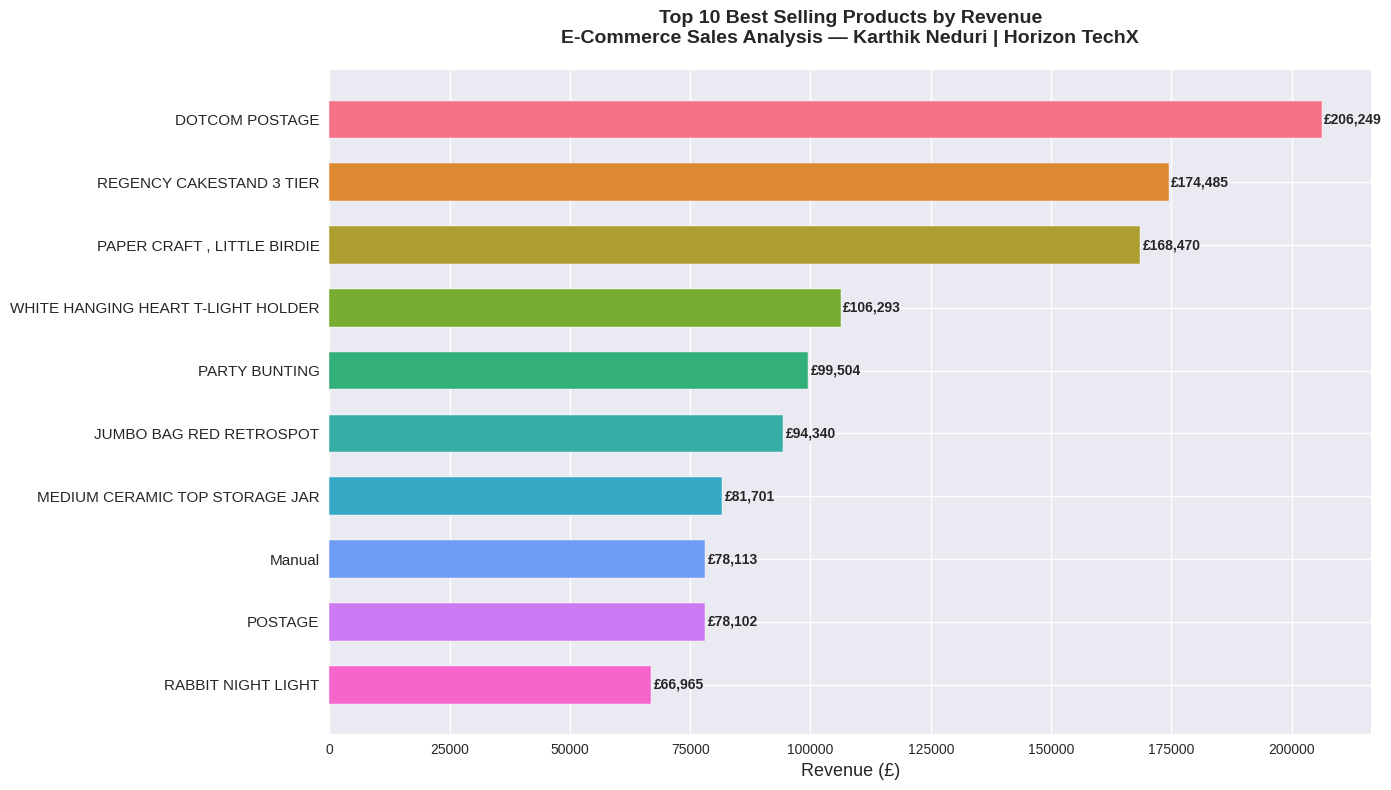

✅ Chart 1 Saved!


In [ ]:
plt.figure(figsize=(14, 8))
top_products_rev = df.groupby('Description')['TotalPrice'].sum()\
                     .sort_values(ascending=False).head(10)

colors = sns.color_palette("husl", 10)
bars = plt.barh(range(10), top_products_rev.values, color=colors, edgecolor='white', height=0.6)
plt.yticks(range(10), [p[:35] for p in top_products_rev.index], fontsize=11)
plt.xlabel('Revenue (£)', fontsize=13)
plt.title('Top 10 Best Selling Products by Revenue\nE-Commerce Sales Analysis — Karthik Neduri | Horizon TechX',
          fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis()

for i, (bar, val) in enumerate(zip(bars, top_products_rev.values)):
    plt.text(val + 500, i, f'£{val:,.0f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('Chart1_Top10_Products_Revenue.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Chart 1 Saved!")

#CHART 2: Top 10 Countries by Revenue

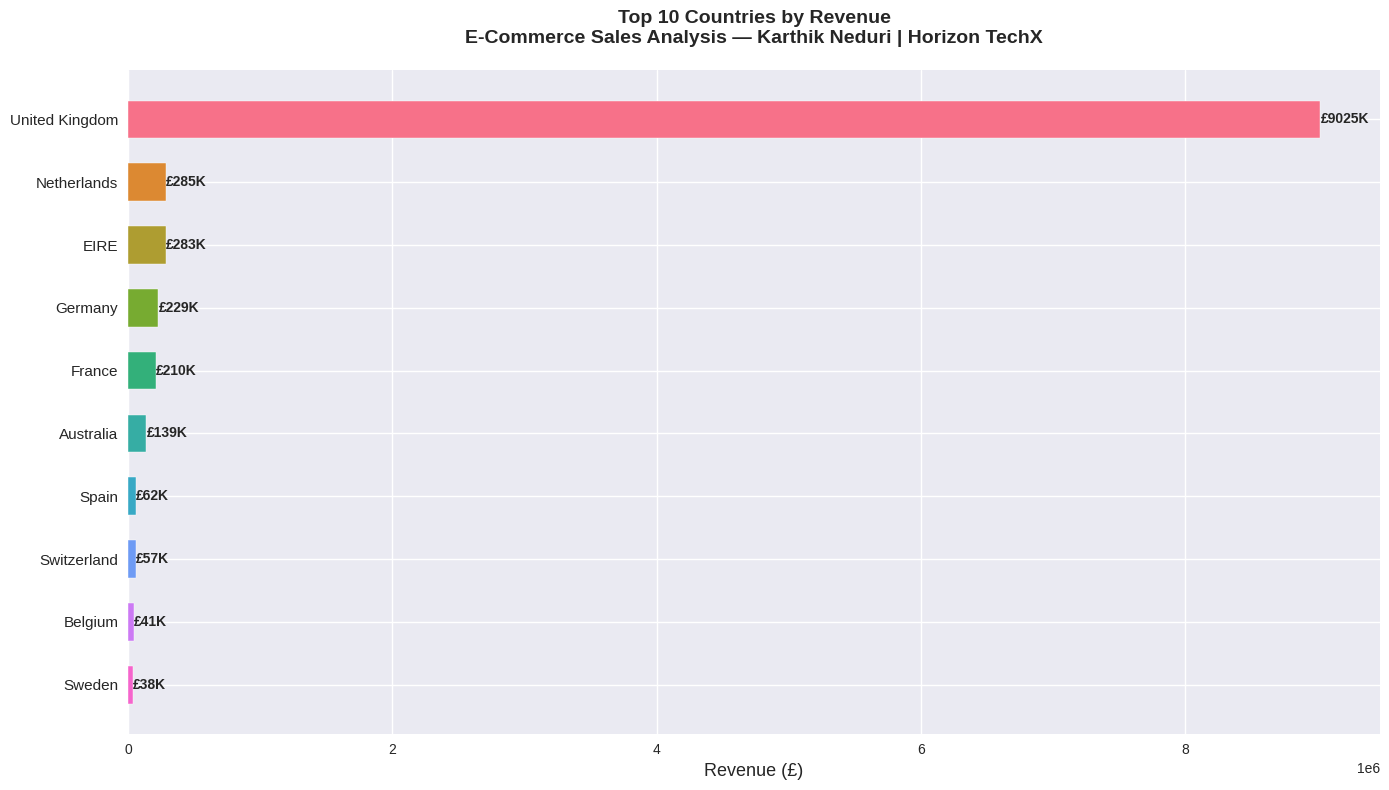

✅ Chart 2 Saved!


In [ ]:
plt.figure(figsize=(14, 8))
top_countries_rev = df.groupby('Country')['TotalPrice'].sum()\
                      .sort_values(ascending=False).head(10)

colors = sns.color_palette("husl", 10)
bars = plt.barh(range(10), top_countries_rev.values, color=colors, edgecolor='white', height=0.6)
plt.yticks(range(10), top_countries_rev.index, fontsize=11)
plt.xlabel('Revenue (£)', fontsize=13)
plt.title('Top 10 Countries by Revenue\nE-Commerce Sales Analysis — Karthik Neduri | Horizon TechX',
          fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis()

for i, (bar, val) in enumerate(zip(bars, top_countries_rev.values)):
    plt.text(val + 500, i, f'£{val/1000:.0f}K', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('Chart2_Top10_Countries_Revenue.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Chart 2 Saved!")

#CHART 3: Monthly Sales Trend

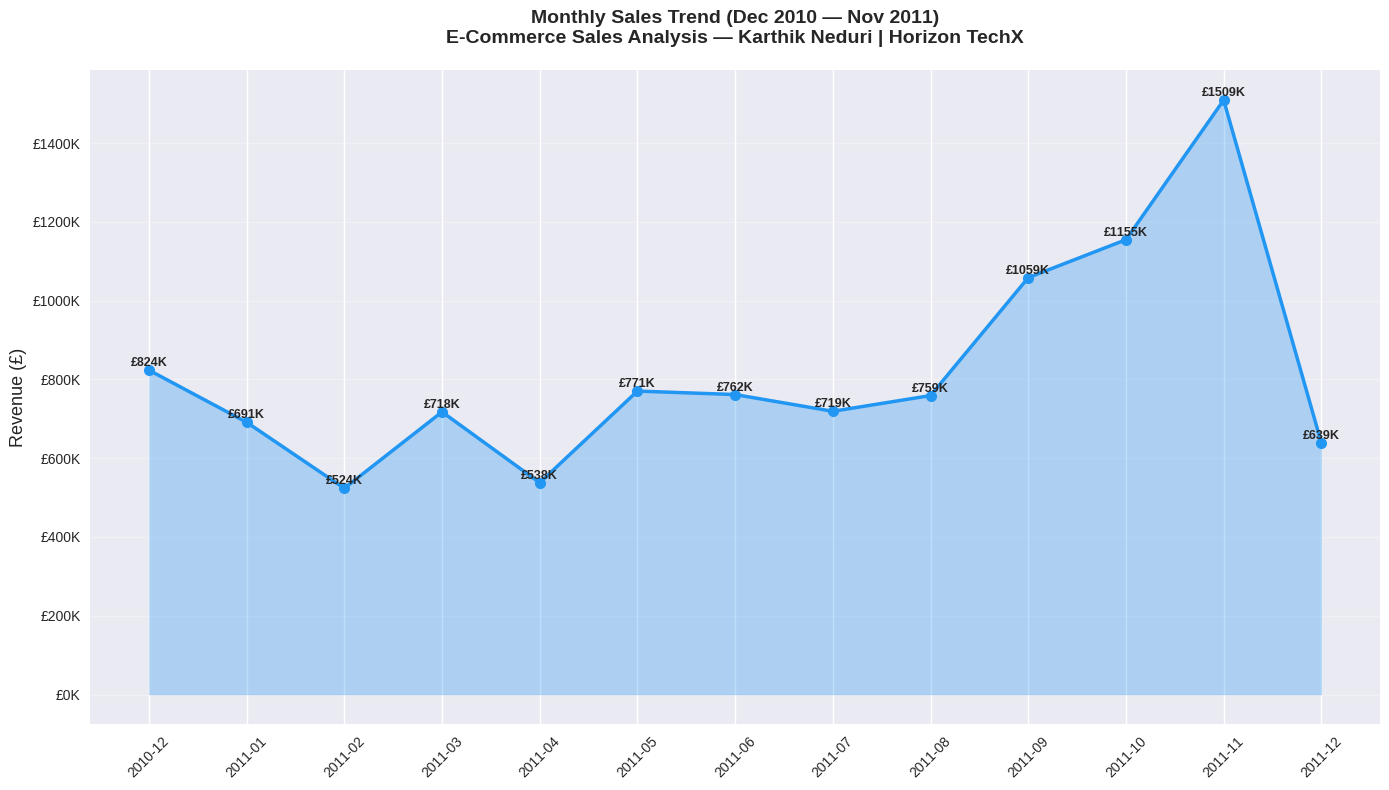

✅ Chart 3 Saved!


In [ ]:
plt.figure(figsize=(14, 8))
monthly_sales = df.groupby(['Year', 'Month'])['TotalPrice'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['Year'].astype(str) + '-' + \
                              monthly_sales['Month'].astype(str).str.zfill(2)
monthly_sales = monthly_sales.sort_values(['Year', 'Month'])

plt.plot(range(len(monthly_sales)), monthly_sales['TotalPrice'].values,
         marker='o', color='#2196F3', linewidth=2.5, markersize=8)
plt.fill_between(range(len(monthly_sales)), monthly_sales['TotalPrice'].values,
                 alpha=0.3, color='#2196F3')

for i, val in enumerate(monthly_sales['TotalPrice'].values):
    plt.text(i, val + 10000, f'£{val/1000:.0f}K', ha='center', fontsize=9, fontweight='bold')

plt.xticks(range(len(monthly_sales)), monthly_sales['YearMonth'].values,
           rotation=45, fontsize=10)
plt.ylabel('Revenue (£)', fontsize=13)
plt.title('Monthly Sales Trend (Dec 2010 — Nov 2011)\nE-Commerce Sales Analysis — Karthik Neduri | Horizon TechX',
          fontsize=14, fontweight='bold', pad=20)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000:.0f}K'))
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Chart3_Monthly_Sales_Trend.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Chart 3 Saved!")

# CHART 4: Revenue by Year

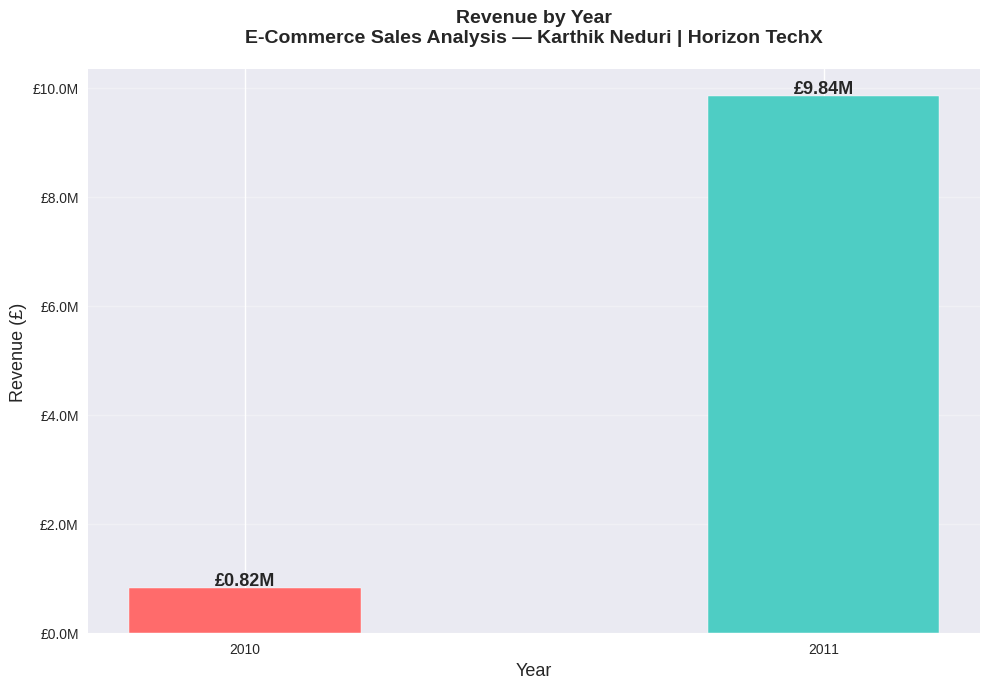

✅ Chart 4 Saved!


In [ ]:
plt.figure(figsize=(10, 7))
yearly_sales = df.groupby('Year')['TotalPrice'].sum()

colors = ['#FF6B6B', '#4ECDC4']
bars = plt.bar(yearly_sales.index.astype(str), yearly_sales.values,
               color=colors, width=0.4, edgecolor='white')

for bar, val in zip(bars, yearly_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 50000,
             f'£{val/1000000:.2f}M', ha='center', fontsize=13, fontweight='bold')

plt.ylabel('Revenue (£)', fontsize=13)
plt.xlabel('Year', fontsize=13)
plt.title('Revenue by Year\nE-Commerce Sales Analysis — Karthik Neduri | Horizon TechX',
          fontsize=14, fontweight='bold', pad=20)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000000:.1f}M'))
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Chart4_Revenue_By_Year.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Chart 4 Saved!")

#CHART 5: Top 10 Customers by Revenue

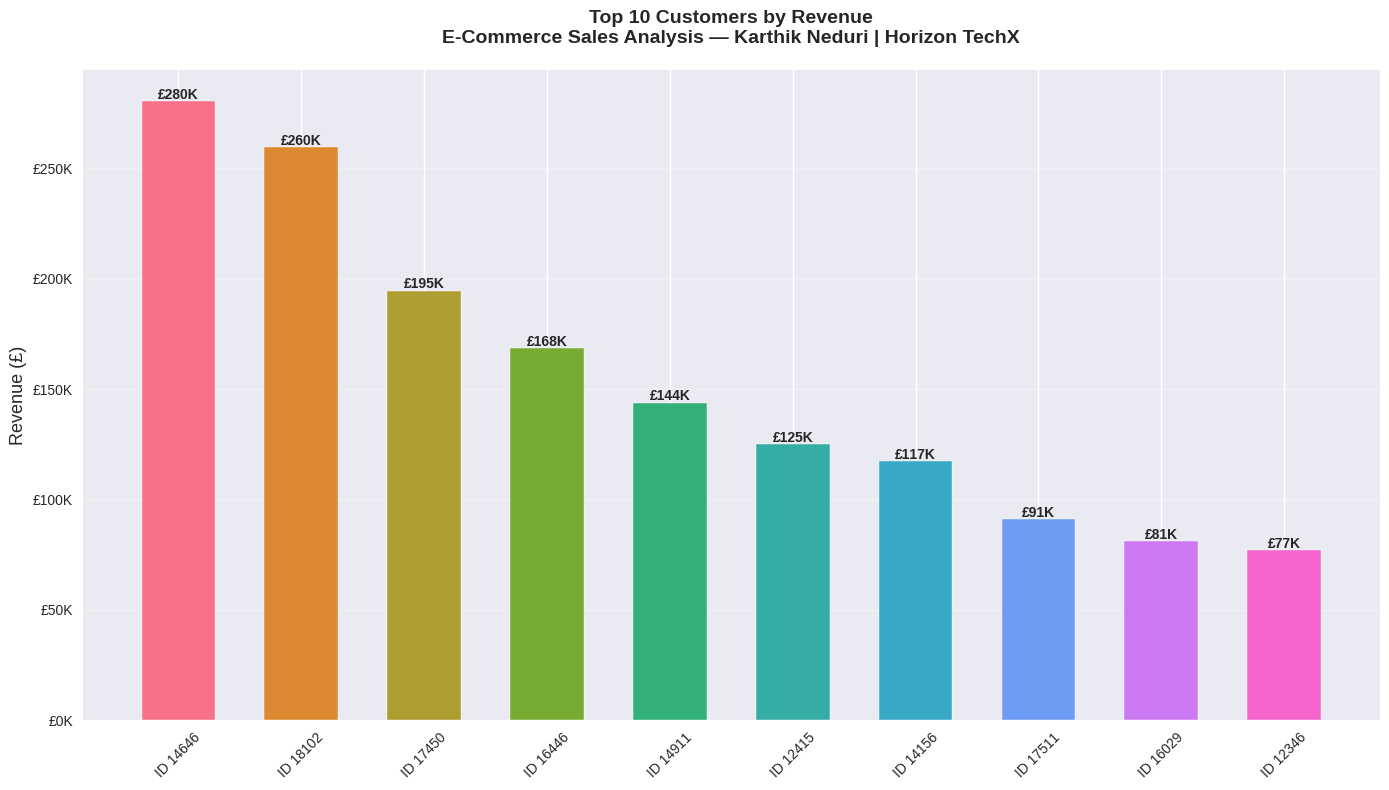

✅ Chart 5 Saved!


In [ ]:
plt.figure(figsize=(14, 8))
top_customers = df.groupby('CustomerID')['TotalPrice'].sum()\
                  .sort_values(ascending=False).head(10)

colors = sns.color_palette("husl", 10)
bars = plt.bar(range(10), top_customers.values, color=colors, edgecolor='white', width=0.6)
plt.xticks(range(10), [f'ID {int(c)}' for c in top_customers.index],
           rotation=45, fontsize=10)
plt.ylabel('Revenue (£)', fontsize=13)
plt.title('Top 10 Customers by Revenue\nE-Commerce Sales Analysis — Karthik Neduri | Horizon TechX',
          fontsize=14, fontweight='bold', pad=20)

for i, (bar, val) in enumerate(zip(bars, top_customers.values)):
    plt.text(i, val + 1000, f'£{val/1000:.0f}K', ha='center', fontsize=10, fontweight='bold')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000:.0f}K'))
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Chart5_Top10_Customers_Revenue.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Chart 5 Saved!")

#CHART 6: Revenue Distribution by Country (Pie Chart)

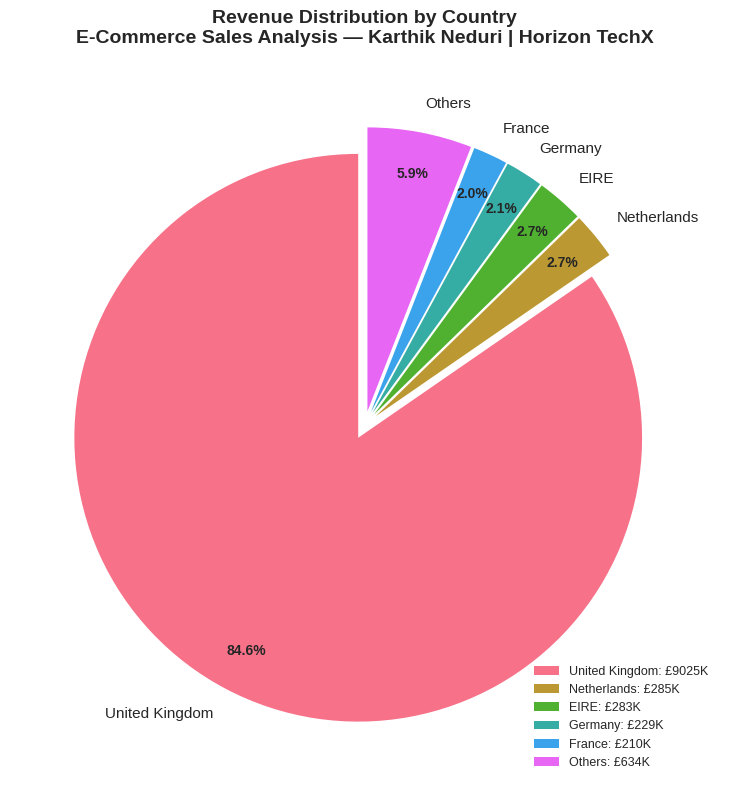

✅ Chart 6 Saved!


In [ ]:
plt.figure(figsize=(12, 8))
top_countries_pie = df.groupby('Country')['TotalPrice'].sum()\
                      .sort_values(ascending=False).head(5)
other_revenue = df.groupby('Country')['TotalPrice'].sum()\
                  .sort_values(ascending=False)[5:].sum()

pie_data = list(top_countries_pie.values) + [other_revenue]
pie_labels = [f'{c}' for c in top_countries_pie.index] + ['Others']
colors = sns.color_palette("husl", 6)
explode = [0.05] * 6

wedges, texts, autotexts = plt.pie(pie_data,
                                    labels=pie_labels,
                                    autopct='%1.1f%%',
                                    colors=colors,
                                    startangle=90,
                                    pctdistance=0.85,
                                    explode=explode)

for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

plt.title('Revenue Distribution by Country\nE-Commerce Sales Analysis — Karthik Neduri | Horizon TechX',
          fontsize=14, fontweight='bold', pad=20)
plt.legend(wedges, [f'{l}: £{v/1000:.0f}K' for l, v in zip(pie_labels, pie_data)],
           loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('Chart6_Revenue_Distribution_Country.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Chart 6 Saved!")

# Step 9: Statistical Analysis & Correlation

#1: Statistical Summary

In [ ]:
print("=" * 60)
print("         STATISTICAL ANALYSIS")
print("=" * 60)

print("\n📊 DETAILED STATISTICAL SUMMARY:")
print("-" * 60)
stats_df = df[['Quantity', 'UnitPrice', 'TotalPrice']].describe()
print(stats_df.round(2))

         STATISTICAL ANALYSIS

📊 DETAILED STATISTICAL SUMMARY:
------------------------------------------------------------
        Quantity  UnitPrice  TotalPrice
count  530104.00  530104.00   530104.00
mean       10.54       3.91       20.12
std       155.52      35.92      270.36
min         1.00       0.00        0.00
25%         1.00       1.25        3.75
50%         3.00       2.08        9.90
75%        10.00       4.13       17.70
max     80995.00   13541.33   168469.60


#2: Skewness & Kurtosis

In [ ]:
print("=" * 60)
print("      SKEWNESS & KURTOSIS ANALYSIS")
print("=" * 60)

print("\n📈 SKEWNESS OF NUMERICAL COLUMNS:")
print("-" * 60)
print(df[['Quantity', 'UnitPrice', 'TotalPrice']].skew().round(2))

print("\n📉 KURTOSIS OF NUMERICAL COLUMNS:")
print("-" * 60)
print(df[['Quantity', 'UnitPrice', 'TotalPrice']].kurtosis().round(2))

      SKEWNESS & KURTOSIS ANALYSIS

📈 SKEWNESS OF NUMERICAL COLUMNS:
------------------------------------------------------------
Quantity      471.73
UnitPrice     206.09
TotalPrice    506.71
dtype: float64

📉 KURTOSIS OF NUMERICAL COLUMNS:
------------------------------------------------------------
Quantity      236462.34
UnitPrice      62483.14
TotalPrice    297651.66
dtype: float64


#3: Correlation Matrix

In [ ]:
print("=" * 60)
print("         CORRELATION MATRIX")
print("=" * 60)

correlation = df[['Quantity', 'UnitPrice', 'TotalPrice']].corr()
print("\n🔗 CORRELATION MATRIX:")
print("-" * 60)
print(correlation.round(2))

         CORRELATION MATRIX

🔗 CORRELATION MATRIX:
------------------------------------------------------------
            Quantity  UnitPrice  TotalPrice
Quantity        1.00      -0.00        0.91
UnitPrice      -0.00       1.00        0.14
TotalPrice      0.91       0.14        1.00


# 4: Revenue Statistics by Country

In [ ]:
print("=" * 60)
print("    REVENUE STATISTICS BY COUNTRY (Top 5)")
print("=" * 60)

country_stats = df.groupby('Country')['TotalPrice'].agg([
    'sum', 'mean', 'count', 'std'
]).round(2).sort_values('sum', ascending=False).head(5)
country_stats.columns = ['Total Revenue', 'Avg Order Value', 'Orders', 'Std Dev']
print("\n🌍 REVENUE STATISTICS BY COUNTRY:")
print("-" * 60)
print(country_stats)

    REVENUE STATISTICS BY COUNTRY (Top 5)

🌍 REVENUE STATISTICS BY COUNTRY:
------------------------------------------------------------
                Total Revenue  Avg Order Value  Orders  Std Dev
Country                                                        
United Kingdom     9025222.08            18.60  485123   281.28
Netherlands         285446.34           121.00    2359   164.05
EIRE                283453.96            35.93    7890    84.60
Germany             228867.14            25.32    9040    35.46
France              209715.11            24.95    8407    74.09


#5: Monthly Revenue Statistics

In [ ]:
import calendar

print("=" * 60)
print("       MONTHLY REVENUE STATISTICS")
print("=" * 60)

monthly_stats = df.groupby('Month')['TotalPrice'].agg([
    'sum', 'mean', 'count'
]).round(2)
monthly_stats.columns = ['Total Revenue', 'Avg Revenue', 'Orders']
monthly_stats.index = [calendar.month_name[m] for m in monthly_stats.index]

print("\n📅 MONTHLY REVENUE STATISTICS:")
print("-" * 60)
print(monthly_stats)

       MONTHLY REVENUE STATISTICS

📅 MONTHLY REVENUE STATISTICS:
------------------------------------------------------------
           Total Revenue  Avg Revenue  Orders
January        691364.56        20.15   34306
February       523631.89        19.32   27105
March          717639.36        20.04   35803
April          537808.62        18.48   29096
May            770536.02        21.31   36164
June           761739.90        21.17   35977
July           719221.19        18.61   38645
August         759138.38        22.01   34483
September     1058590.17        21.49   49261
October       1154979.30        19.48   59304
November      1509496.33        18.11   83369
December      1462538.82        21.96   66591


#6: Correlation Heatmap Chart

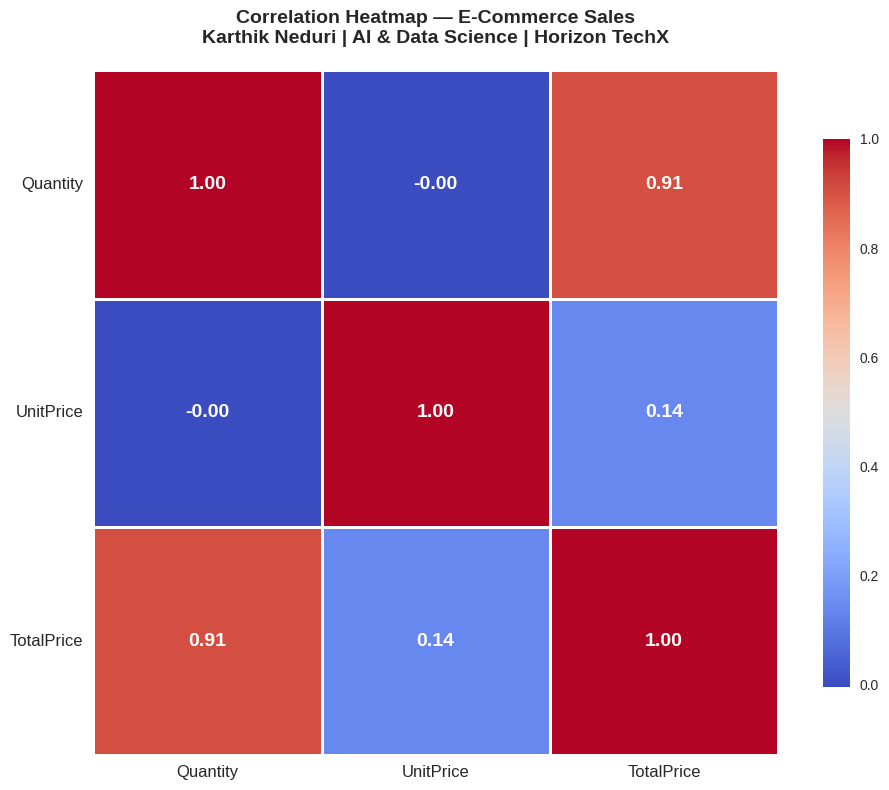

✅ Correlation Heatmap Saved!


In [ ]:

plt.figure(figsize=(10, 8))
correlation = df[['Quantity', 'UnitPrice', 'TotalPrice']].corr()

sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=1,
            square=True,
            annot_kws={'size': 14, 'weight': 'bold'},
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Heatmap — E-Commerce Sales\nKarthik Neduri | AI & Data Science | Horizon TechX',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)

plt.tight_layout()
plt.savefig('Chart7_Correlation_Heatmap.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Correlation Heatmap Saved!")

#7: Revenue Distribution Chart

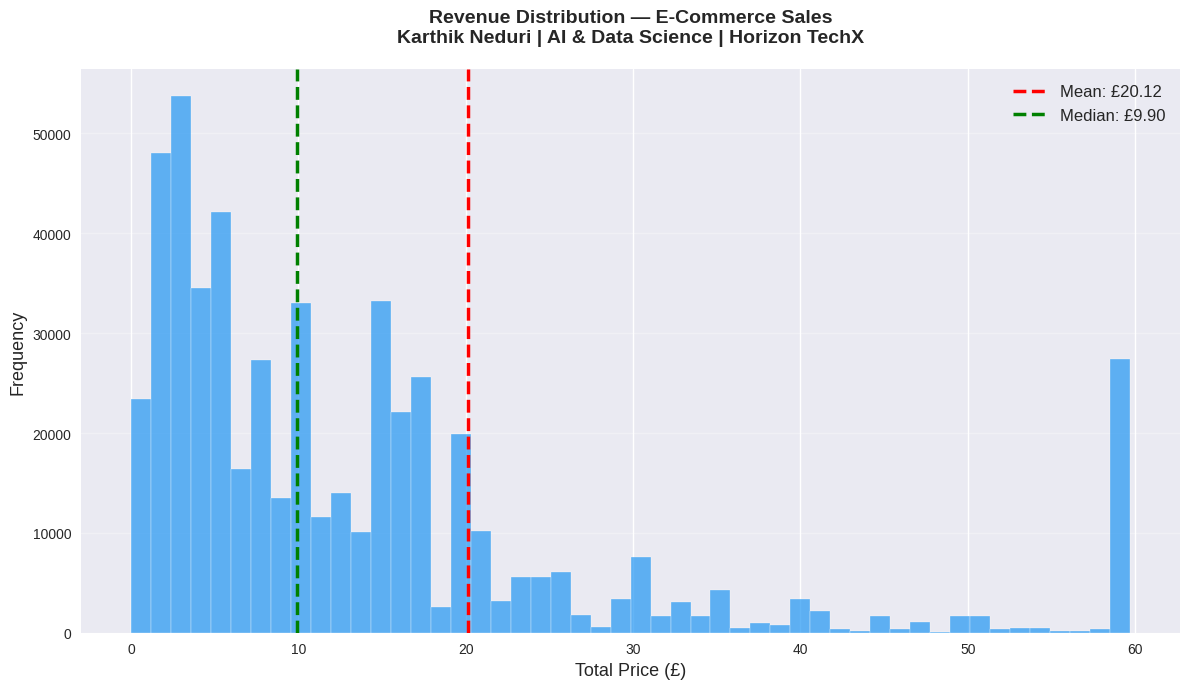

✅ Revenue Distribution Chart Saved!


In [ ]:
plt.figure(figsize=(12, 7))

plt.hist(df['TotalPrice'].clip(upper=df['TotalPrice'].quantile(0.95)),
         bins=50,
         color='#2196F3',
         edgecolor='white',
         alpha=0.7)

plt.axvline(df['TotalPrice'].mean(),
            color='red',
            linestyle='--',
            linewidth=2.5,
            label=f'Mean: £{df["TotalPrice"].mean():.2f}')

plt.axvline(df['TotalPrice'].median(),
            color='green',
            linestyle='--',
            linewidth=2.5,
            label=f'Median: £{df["TotalPrice"].median():.2f}')

plt.xlabel('Total Price (£)', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.title('Revenue Distribution — E-Commerce Sales\nKarthik Neduri | AI & Data Science | Horizon TechX',
          fontsize=14, fontweight='bold', pad=20)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Chart8_Revenue_Distribution.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Revenue Distribution Chart Saved!")